In [1]:
import pandas as pd
import json
import math
import os
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
from sklearn.metrics import r2_score
import wandb
wandb.login(key="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")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\TRAN DUY AN\_netrc
wandb: Currently logged in as: duyan642005 (duyan642005-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [2]:
#kiểm tra coi có GPU khong?
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"{device.type.upper()}")

CUDA


In [20]:
GEO_PATH = r"C:\Users\TRAN DUY AN\Downloads\PEMSD4\PEMSD4.geo"
REL_PATH = r"C:\Users\TRAN DUY AN\Downloads\PEMSD4\PEMSD4.rel"
DYNA_PATH = r"C:\Users\TRAN DUY AN\Downloads\PEMSD4\PEMSD4.dyna"
CONFIG_PATH = r"C:\Users\TRAN DUY AN\Downloads\PEMSD4\config.json"

In [21]:
def load_raw_data():
    geo_df = pd.read_csv(GEO_PATH)
    print(f"[Geo] Kích thước: {geo_df.shape} | Các cột: {list(geo_df.columns)}")

    rel_df = pd.read_csv(REL_PATH)
    print(f"[Rel] Kích thước: {rel_df.shape} | Các cột: {list(rel_df.columns)}")

    dyna_df = pd.read_csv(DYNA_PATH)
    print(f"[Dyna] Kích thước: {dyna_df.shape} | Các cột: {list(dyna_df.columns)}")

    config_data = {}
    if os.path.exists(CONFIG_PATH):
        with open(CONFIG_PATH, 'r') as f:
            config_data = json.load(f)
        print(f"[Config] Đã tải thành công tệp cấu hình.")
    else:
        print(f"[Config] CẢNH BÁO: Không tìm thấy '{CONFIG_PATH}'.")
        
    return geo_df, rel_df, dyna_df

In [22]:
def build_adjacency_matrix(geo_df, rel_df, epsilon=0.1):
    real_ids = geo_df['geo_id'].values
    num_nodes = len(real_ids)
    id_to_index = {real_id: idx for idx, real_id in enumerate(real_ids)}

    adj_matrix = np.zeros((num_nodes, num_nodes), dtype=np.float32)

    valid_edges = rel_df[rel_df['origin_id'].isin(id_to_index) & rel_df['destination_id'].isin(id_to_index)]
    std_dist = valid_edges['cost'].std()

    for _, row in valid_edges.iterrows():
        i = id_to_index[row['origin_id']]
        j = id_to_index[row['destination_id']]
        dist = row['cost']
        weight = np.exp(- (dist**2) / (std_dist**2))
        
        # BỘ LỌC NGƯỠNG: Chỉ giữ lại các trọng số mạnh
        if weight >= epsilon:
            adj_matrix[i, j] = weight

    adj_matrix = adj_matrix + np.eye(num_nodes)
    degree = np.array(adj_matrix.sum(axis=1))
    d_inv_sqrt = np.power(degree, -0.5).flatten()
    d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.0 # Bắt lỗi an toàn nếu có nút cô lập 
    d_mat_inv_sqrt = np.diag(d_inv_sqrt)
    normalized_adj = d_mat_inv_sqrt.dot(adj_matrix).dot(d_mat_inv_sqrt)
    normalized_adj = normalized_adj.astype(np.float32)
    
    print(f"-> Hoàn tất! Kích thước Ma trận Laplacian chuẩn hóa đối xứng: {normalized_adj.shape}\n")
    return normalized_adj, id_to_index, num_nodes

In [23]:
def build_raw_tensor(dyna_df, id_to_index, num_nodes):
    feature_cols = ['traffic_flow', 'traffic_occupancy', 'traffic_speed']
    num_features = len(feature_cols)
    
    dyna_df['time'] = pd.to_datetime(dyna_df['time'])
    unique_times = pd.DatetimeIndex(np.sort(dyna_df['time'].unique()))
    num_time_steps = len(unique_times)
    
    time_to_index = {t: idx for idx, t in enumerate(unique_times)}

    tensor_3d = np.full((num_time_steps, num_nodes, num_features), np.nan, dtype=np.float32)

    dyna_df['time_idx'] = dyna_df['time'].map(time_to_index)
    dyna_df['node_idx'] = dyna_df['entity_id'].map(id_to_index)

    valid_df = dyna_df.dropna(subset=['time_idx', 'node_idx']) 

    t_idx = valid_df['time_idx'].astype(int).values
    n_idx = valid_df['node_idx'].astype(int).values

    tensor_3d[t_idx, n_idx, 0] = valid_df['traffic_flow'].values
    tensor_3d[t_idx, n_idx, 1] = valid_df['traffic_occupancy'].values
    tensor_3d[t_idx, n_idx, 2] = valid_df['traffic_speed'].values

    print(f"-> Đã tạo Tensor thô (giữ nguyên NaNs). Kích thước: {tensor_3d.shape}")
    return tensor_3d, unique_times

In [24]:
def impute_with_ha(data_split, time_split, train_ha_map=None):
    num_steps, num_nodes, num_features = data_split.shape
    tensor_2d = data_split.reshape(num_steps, -1)
    df = pd.DataFrame(tensor_2d, index=time_split)
    
    # Đổi thành forward để nội suy thuận chiều, ngăn rò rỉ dữ liệu
    df = df.interpolate(method='linear', limit=3, limit_direction='forward')
    
    time_of_day = df.index.time
    
    if train_ha_map is None:
        train_ha_map = df.groupby(time_of_day).mean()
        
    ha_aligned = pd.DataFrame(index=df.index)
    ha_aligned['time_of_day'] = time_of_day
    ha_aligned = ha_aligned.join(train_ha_map, on='time_of_day').drop(columns=['time_of_day'])
    
    df = df.fillna(ha_aligned)
    
    df = df.ffill().fillna(0)
    
    return df.values.reshape(num_steps, num_nodes, num_features).astype(np.float32), train_ha_map

In [25]:
class SpatioTemporalDataset(Dataset):
    def __init__(self, data, seq_len, pred_len):
        # Chuyển đổi sang Tensor MỘT LẦN duy nhất để chia sẻ bộ nhớ
        if isinstance(data, np.ndarray):
            self.data = torch.from_numpy(data).float()
        else:
            self.data = data.clone().detach().float()
            
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return self.data.shape[0] - self.seq_len - self.pred_len + 1

    def __getitem__(self, index):
        # Dữ liệu đã là Tensor, không gọi hàm torch.tensor() ở đây nữa
        x = self.data[index : index + self.seq_len, :, :]
        y = self.data[index + self.seq_len : index + self.seq_len + self.pred_len, :, 0:1]
        return x, y

def get_dataloader(data, seq_len, pred_len, batch_size, shuffle):
    dataset = SpatioTemporalDataset(data, seq_len, pred_len)
    # Tăng num_workers để load dữ liệu đa luồng
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=True, pin_memory=True, num_workers=0)

In [26]:
EPSILON = 0.1      
SEQ_LEN = 12       
PRED_LEN = 12      
BATCH_SIZE = 8    

In [27]:
print("\n[BƯỚC 1] Tải dữ liệu thô...")
geo_df, rel_df, dyna_df = load_raw_data()

print("\n[BƯỚC 2] Xây dựng Đồ thị Không gian")
normalized_adj, id_to_index, num_nodes = build_adjacency_matrix(geo_df, rel_df, EPSILON)
print(f"-> Laplacian Shape: {normalized_adj.shape}")

print("\n[BƯỚC 3] Chuyển hóa chuỗi Thời gian thành Tensor")
tensor_3d_raw, unique_times = build_raw_tensor(dyna_df, id_to_index, num_nodes)

print("\n[BƯỚC 4] Cắt tập dữ liệu")
total_steps = tensor_3d_raw.shape[0]
train_steps, val_steps = int(total_steps * 0.6), int(total_steps * 0.2)

train_data_raw = tensor_3d_raw[:train_steps]
val_data_raw = tensor_3d_raw[train_steps:train_steps+val_steps]
test_data_raw = tensor_3d_raw[train_steps+val_steps:]

train_times = unique_times[:train_steps]
val_times = unique_times[train_steps:train_steps+val_steps]
test_times = unique_times[train_steps+val_steps:]

print("\n[BƯỚC 5] Lấp dữ liệu khuyết bằng HA")
train_data, train_ha_map = impute_with_ha(train_data_raw, train_times, train_ha_map=None)
val_data, _ = impute_with_ha(val_data_raw, val_times, train_ha_map=train_ha_map)
test_data, _ = impute_with_ha(test_data_raw, test_times, train_ha_map=train_ha_map)

print("\n[BƯỚC 6] Chuẩn hóa Z-Score")
mean = train_data.astype(np.float64).mean(axis=(0, 1), keepdims=True).astype(np.float32)
std = train_data.astype(np.float64).std(axis=(0, 1), keepdims=True).astype(np.float32)
std = np.where(std == 0, 1.0, std)

train_scaled = (train_data - mean) / std
val_scaled = (val_data - mean) / std
test_scaled = (test_data - mean) / std

flow_mean, flow_std = mean[0, 0, 0], std[0, 0, 0]
print(f"-> Flow Mean: {flow_mean:.2f} | Flow Std: {flow_std:.2f}")

print("\n[BƯỚC 7] Đóng gói(Sẵn sàng Huấn luyện!)")
train_loader = get_dataloader(train_scaled, SEQ_LEN, PRED_LEN, BATCH_SIZE, shuffle=True)
val_loader = get_dataloader(val_scaled, SEQ_LEN, PRED_LEN, BATCH_SIZE, shuffle=False)
test_loader = get_dataloader(test_scaled, SEQ_LEN, PRED_LEN, BATCH_SIZE, shuffle=False)

for batch_x, batch_y in train_loader:
    print(f"\n✅ HOÀN TẤT TOÀN BỘ TIỀN XỬ LÝ!")
    print(f"-> Input (X) shape:  {batch_x.shape}")
    print(f"-> Target (Y) shape: {batch_y.shape}")
    break


[BƯỚC 1] Tải dữ liệu thô...
[Geo] Kích thước: (307, 3) | Các cột: ['geo_id', 'type', 'coordinates']
[Rel] Kích thước: (340, 5) | Các cột: ['rel_id', 'type', 'origin_id', 'destination_id', 'cost']
[Dyna] Kích thước: (5216544, 7) | Các cột: ['dyna_id', 'type', 'time', 'entity_id', 'traffic_flow', 'traffic_occupancy', 'traffic_speed']
[Config] Đã tải thành công tệp cấu hình.

[BƯỚC 2] Xây dựng Đồ thị Không gian
-> Hoàn tất! Kích thước Ma trận Laplacian: (307, 307)

-> Laplacian Shape: (307, 307)

[BƯỚC 3] Chuyển hóa chuỗi Thời gian thành Tensor
-> Đã tạo Tensor thô (giữ nguyên NaNs). Kích thước: (16992, 307, 3)

[BƯỚC 4] Cắt tập dữ liệu

[BƯỚC 5] Lấp dữ liệu khuyết bằng HA

[BƯỚC 6] Chuẩn hóa Z-Score
-> Flow Mean: 207.24 | Flow Std: 156.48

[BƯỚC 7] Đóng gói(Sẵn sàng Huấn luyện!)

✅ HOÀN TẤT TOÀN BỘ TIỀN XỬ LÝ!
-> Input (X) shape:  torch.Size([8, 12, 307, 3])
-> Target (Y) shape: torch.Size([8, 12, 307, 1])


In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GATv2Layer(nn.Module): #tách dữ liệu không gian
    def __init__(self, in_features, out_features, num_heads=1, dropout=0.1): 
        super(GATv2Layer, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.num_heads = num_heads
        self.head_dim = out_features // num_heads
        
        self.lin_src = nn.Linear(in_features, num_heads * self.head_dim, bias=False)
        self.lin_dst = nn.Linear(in_features, num_heads * self.head_dim, bias=False)
        
        self.attn_vec = nn.Parameter(torch.Tensor(1, num_heads, self.head_dim))
        self.dropout = nn.Dropout(dropout)
        self.leaky_relu = nn.LeakyReLU(0.2)
        
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.lin_src.weight)
        nn.init.xavier_uniform_(self.lin_dst.weight)
        nn.init.xavier_uniform_(self.attn_vec)

    def forward(self, x, adj):
        B, T, N, _ = x.shape
        x_flat = x.reshape(B * T, N, self.in_features)
        
        h_src = self.lin_src(x_flat).view(B * T, N, self.num_heads, self.head_dim)
        h_dst = self.lin_dst(x_flat).view(B * T, N, self.num_heads, self.head_dim)
        
        adj_mask = adj.unsqueeze(0).unsqueeze(-1)
        zero_mask = (adj_mask == 0)
      
        chunk_size = 32  
        total_items = B * T
        out_chunks = []
        
        for i in range(0, total_items, chunk_size):
            h_src_chunk = h_src[i : i + chunk_size].unsqueeze(2) 
            h_dst_chunk = h_dst[i : i + chunk_size].unsqueeze(1) 
            
            attn_scores_chunk = self.leaky_relu(h_src_chunk + h_dst_chunk)
            attn_scores_chunk = (attn_scores_chunk * self.attn_vec).sum(dim=-1) 
            
            attn_scores_chunk = attn_scores_chunk.masked_fill(zero_mask, float('-inf'))
            
            attn_weights_chunk = F.softmax(attn_scores_chunk, dim=2)
            attn_weights_chunk = self.dropout(attn_weights_chunk)
            
            h_dst_prime_chunk = h_dst_chunk.squeeze(1) 
            out_chunk = torch.einsum('cijh,cjhd->cihd', attn_weights_chunk, h_dst_prime_chunk)
            
            out_chunks.append(out_chunk)
            
        out = torch.cat(out_chunks, dim=0)
        out = out.reshape(B, T, N, self.num_heads * self.head_dim)
        
        return out


class MambaS6Cell(nn.Module):
    """
    Khối Selective State Space (S6).
    Đã điều chỉnh d_state và d_conv mặc định nhỏ gọn hơn.
    """
    def __init__(self, d_model, d_state=8, d_conv=2, expand=2):
        super(MambaS6Cell, self).__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_inner = expand * d_model
        
        self.in_proj = nn.Linear(d_model, self.d_inner * 2, bias=False)
        self.conv = nn.Conv1d(self.d_inner, self.d_inner, kernel_size=d_conv, padding=d_conv-1, groups=self.d_inner)
        
        self.x_proj = nn.Linear(self.d_inner, self.d_state * 2 + d_model, bias=False)
        self.dt_proj = nn.Linear(d_model, self.d_inner, bias=True)
        
        self.A_log = nn.Parameter(torch.log(torch.arange(1, self.d_state + 1).float().repeat(self.d_inner, 1)))
        self.D = nn.Parameter(torch.ones(self.d_inner))
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)

    def forward(self, x):
        B_N, T, D = x.shape
        
        xz = self.in_proj(x) 
        x_act, z = xz.chunk(2, dim=-1)
        
        x_act = x_act.transpose(1, 2) 
        x_act = self.conv(x_act)[:, :, :T] 
        x_act = x_act.transpose(1, 2) 
        x_act = F.silu(x_act)
        
        x_db = self.x_proj(x_act) 
        dt, B, C = torch.split(x_db, [self.d_model, self.d_state, self.d_state], dim=-1)
        dt = F.softplus(self.dt_proj(dt)) 
        
        A = -torch.exp(self.A_log) 
        
        h = torch.zeros(B_N, self.d_inner, self.d_state, device=x.device)
        y = torch.zeros(B_N, T, self.d_inner, device=x.device)
        
        for t in range(T):
            dt_t = dt[:, t, :].unsqueeze(-1) 
            B_t = B[:, t, :].unsqueeze(1)    
            C_t = C[:, t, :].unsqueeze(-1)   
            x_t = x_act[:, t, :].unsqueeze(-1) 
            
            dA = torch.exp(dt_t * A.unsqueeze(0)) 
            dB = dt_t * B_t 
            
            h = dA * h + dB * x_t
            
            y_t = torch.bmm(h, C_t).squeeze(-1) 
            y[:, t, :] = y_t
            
        y = y * F.silu(z)
        y = y + x_act * self.D.unsqueeze(0).unsqueeze(0)
        
        return self.out_proj(y)


    
# 3. HYBRID ST-MAMBA COMPLETE NETWORK

try:
    from mamba_ssm import Mamba
    HAS_MAMBA = True
except ImportError:
    HAS_MAMBA = False

class STMambaHybridModel(nn.Module):
    def __init__(self, num_nodes, in_features, seq_len, pred_len, d_model=16, d_state=8):
        super(STMambaHybridModel, self).__init__()
        self.num_nodes = num_nodes
        self.pred_len = pred_len
        self.d_model = d_model
        
        self.input_mapping = nn.Linear(in_features, d_model)
        self.spatial_embedding = nn.Parameter(torch.randn(1, 1, num_nodes, d_model))
        
        self.gat_layer1 = GATv2Layer(in_features=d_model, out_features=d_model, num_heads=1)
        
        self.temporal_mamba = MambaS6Cell(d_model=d_model, d_state=d_state)
        
        self.regression = nn.Sequential(
            nn.Linear(seq_len * d_model, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, pred_len * 1) 
        )

    def forward(self, x, adj_matrix):
        B, T, N, F_in = x.shape
        
        h = self.input_mapping(x) 
        h = h + self.spatial_embedding
        
        h_spatial = self.gat_layer1(h, adj_matrix)
        h = h + F.relu(h_spatial) 
        
        # Cấu trúc lại để quét Mamba 1 chiều: [B, T, N, D] -> [B*N, T, D]
        h_rnn = h.transpose(1, 2).reshape(B * N, T, self.d_model)
        
        h_temporal = self.temporal_mamba(h_rnn) 
        
        # Trả lại cấu trúc: [B*N, T, D] -> [B, N, T, D]
        h_temporal = h_temporal.view(B, N, T, self.d_model)
        
        # Phẳng hóa: [B, N, T * D]
        h_flat = h_temporal.reshape(B, N, T * self.d_model)
        
        out = self.regression(h_flat) 
        out = out.view(B, N, self.pred_len, 1).transpose(1, 2)
        
        return out

In [29]:
D_MODEL = 16
D_STATE = 8
adj_tensor = torch.tensor(normalized_adj, dtype=torch.float32).to(device)

In [30]:
model = STMambaHybridModel(
    num_nodes=num_nodes, 
    in_features=3, 
    seq_len=SEQ_LEN, 
    pred_len=PRED_LEN, 
    d_model=D_MODEL, 
    d_state=D_STATE
).to(device)

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

print(model)

model.train()
for batch_x, batch_y in train_loader:
    # batch_x: [32, 12, 307, 3] | batch_y: [32, 12, 307, 1]
    batch_x = batch_x.to(device)
    batch_y = batch_y.to(device)
    
    outputs = model(batch_x, adj_tensor)
    
    loss = criterion(outputs, batch_y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    print(f"Thử nghiệm kiến trúc thành công! Mức Loss batch đầu tiên: {loss.item():.4f}")
    break

STMambaHybridModel(
  (input_mapping): Linear(in_features=3, out_features=16, bias=True)
  (gat_layer1): GATv2Layer(
    (lin_src): Linear(in_features=16, out_features=16, bias=False)
    (lin_dst): Linear(in_features=16, out_features=16, bias=False)
    (dropout): Dropout(p=0.1, inplace=False)
    (leaky_relu): LeakyReLU(negative_slope=0.2)
  )
  (temporal_mamba): MambaS6Cell(
    (in_proj): Linear(in_features=16, out_features=64, bias=False)
    (conv): Conv1d(32, 32, kernel_size=(2,), stride=(1,), padding=(1,), groups=32)
    (x_proj): Linear(in_features=32, out_features=32, bias=False)
    (dt_proj): Linear(in_features=16, out_features=32, bias=True)
    (out_proj): Linear(in_features=32, out_features=16, bias=False)
  )
  (regression): Sequential(
    (0): Linear(in_features=192, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=12, bias=True)
  )
)
Thử nghiệm kiến trúc thành công! Mức Loss batch đầu tiê

In [31]:
import torch
import numpy as np
from tqdm import tqdm 

EPOCHS = 30
best_val_loss = float('inf')
save_path = "best_st_mamba_model.pth"

# 📝 BƯỚC A: Khởi tạo phiên làm việc với WandB cho mô hình ST-Mamba
# (Project đặt giống nhau cho 3 model, name đặt riêng để phân biệt đồ thị)
wandb.init(
    project="DPL302m_Project",
    name="ST_Mamba_Final", 
    config={
        "d_model": D_MODEL,
        "d_state": D_STATE,
        "epochs": EPOCHS,
        "learning_rate": 0.001,
        "optimizer": "AdamW",
        "architecture": "ST-Mamba"
    }
)

def evaluate(loader, model, criterion, adj, flow_mean, flow_std, device):
    model.eval() 
    total_loss = 0.0
    total_mae = 0.0
    num_samples = 0
    
    with torch.no_grad(): 
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            outputs = model(batch_x, adj)
            loss = criterion(outputs, batch_y)
            
            total_loss += loss.item() * batch_x.size(0)

            outputs_real = outputs * flow_std + flow_mean
            batch_y_real = batch_y * flow_std + flow_mean
            
            mae = torch.abs(outputs_real - batch_y_real).mean().item()
            total_mae += mae * batch_x.size(0)
            
            num_samples += batch_x.size(0)
            
    return total_loss / num_samples, total_mae / num_samples

print("BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH ST-MAMBA")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    num_samples = 0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    
    for batch_x, batch_y in loop:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(batch_x, adj_tensor)
        loss = criterion(outputs, batch_y)

        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        
        optimizer.step()
        
        train_loss += loss.item() * batch_x.size(0)
        num_samples += batch_x.size(0)

        loop.set_postfix(loss=loss.item())
        
    avg_train_loss = train_loss / num_samples
    
    val_loss, val_mae = evaluate(val_loader, model, criterion, adj_tensor, flow_mean, flow_std, device)
    
    print(f"✅ Epoch {epoch+1:02d}/{EPOCHS} | Train MSE: {avg_train_loss:.4f} | Val MSE: {val_loss:.4f} | Val MAE: {val_mae:.2f} (xe)")

    # 📝 BƯỚC B: Đẩy các chỉ số lên Server để vẽ biểu đồ line chart thời gian thực
    wandb.log({
        "epoch": epoch + 1,
        "Train MSE": avg_train_loss,
        "Val MSE": val_loss,
        "Val MAE": val_mae
    })

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), save_path)
        print(f"   -> Đã lưu Checkpoint mới! (Cải thiện Val Loss)")

# 📝 BƯỚC C: Đồng bộ nốt dữ liệu cuối cùng và ngắt kết nối an toàn sau khi hết 30 Epochs
wandb.finish()

print("\n HOÀN TẤT HUẤN LUYỆN!")
print(f"Model tốt nhất đã được lưu tại: {save_path}")

BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH ST-MAMBA


✅ Epoch 01/30 | Train MSE: 0.1167 | Val MSE: 0.0772 | Val MAE: 28.87 (xe)
   -> Đã lưu Checkpoint mới! (Cải thiện Val Loss)


✅ Epoch 02/30 | Train MSE: 0.0725 | Val MSE: 0.0737 | Val MAE: 28.00 (xe)
   -> Đã lưu Checkpoint mới! (Cải thiện Val Loss)


✅ Epoch 03/30 | Train MSE: 0.0694 | Val MSE: 0.0722 | Val MAE: 27.79 (xe)
   -> Đã lưu Checkpoint mới! (Cải thiện Val Loss)


✅ Epoch 04/30 | Train MSE: 0.0672 | Val MSE: 0.0670 | Val MAE: 26.65 (xe)
   -> Đã lưu Checkpoint mới! (Cải thiện Val Loss)


...

✅ Epoch 28/30 | Train MSE: 0.0606 | Val MSE: 0.0590 | Val MAE: 24.91 (xe)


✅ Epoch 29/30 | Train MSE: 0.0605 | Val MSE: 0.0591 | Val MAE: 24.75 (xe)


✅ Epoch 30/30 | Train MSE: 0.0604 | Val MSE: 0.0599 | Val MAE: 26.01 (xe)


Train MSE,█▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Val MAE,█▇▆▄▄▃▃▃▃▃▃▂▅▂▂▂▂▂▅▂▃▂▁▁▂▃▂▁▁▃
Val MSE,█▇▆▄▄▃▃▂▂▃▂▂▂▂▂▂▁▂▃▂▂▁▁▁▁▁▂▁▁▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
Train MSE,0.06036
Val MAE,26.00913
Val MSE,0.05992
epoch,30



 HOÀN TẤT HUẤN LUYỆN!
Model tốt nhất đã được lưu tại: best_st_mamba_model.pth


TẢI TRỌNG SỐ MÔ HÌNH TỐT NHẤT
THỰC HIỆN DỰ BÁO


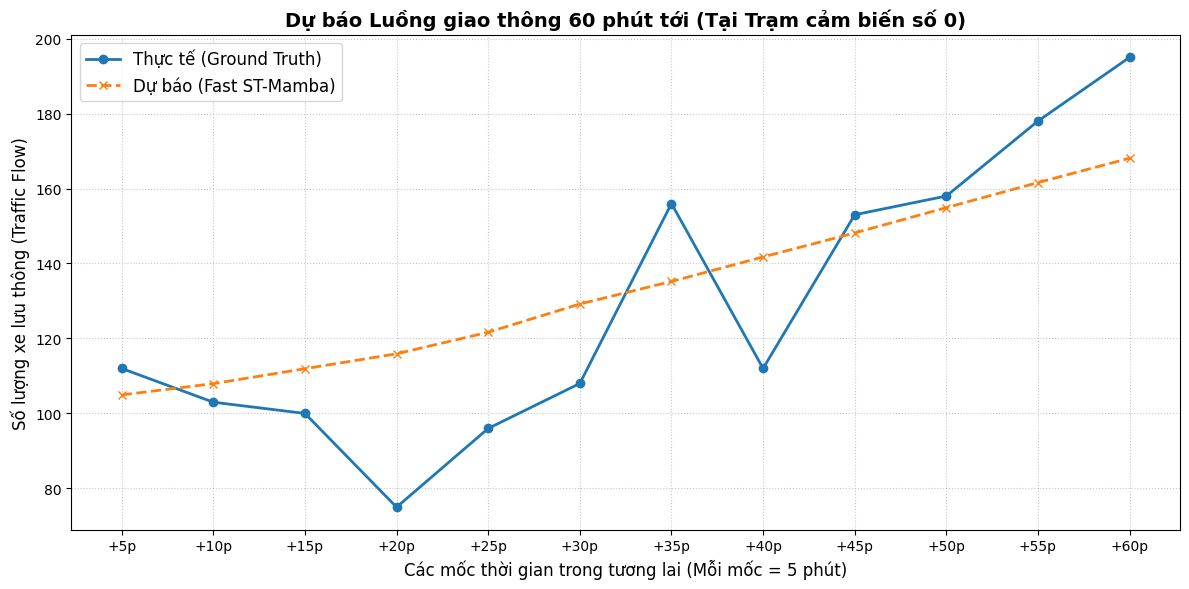

In [32]:
import matplotlib.pyplot as plt
import torch

print("TẢI TRỌNG SỐ MÔ HÌNH TỐT NHẤT")
model.load_state_dict(torch.load(save_path))
model.eval()

# Lấy thử 1 Batch từ tập Dữ liệu Kiểm thử (Test Data)
test_batch_x, test_batch_y = next(iter(test_loader))
test_batch_x = test_batch_x.to(device)
test_batch_y = test_batch_y.to(device)

print("THỰC HIỆN DỰ BÁO")
with torch.no_grad():
    preds = model(test_batch_x, adj_tensor)

# GIẢI CHUẨN HÓA (Đưa về số lượng xe thực tế)
preds_real = preds * flow_std + flow_mean
y_real = test_batch_y * flow_std + flow_mean

preds_real = preds_real.cpu().numpy()
y_real = y_real.cpu().numpy()

# VẼ BIỂU ĐỒ TRỰC QUAN HÓA
sample_idx = 0   # Chọn ngẫu nhiên mẫu đầu tiên trong batch
node_idx = 0     # Chọn Trạm cảm biến giao thông số 0 (Bạn có thể đổi số này từ 0 đến 306)

# Shape hiện tại: [Batch, Time, Node, Feature]
pred_series = preds_real[sample_idx, :, node_idx, 0]
true_series = y_real[sample_idx, :, node_idx, 0]

plt.figure(figsize=(12, 6))

# Vẽ đường thực tế
plt.plot(true_series, label="Thực tế (Ground Truth)", marker='o', linewidth=2, color='#1f77b4')

# Vẽ đường dự báo của ST-Mamba
plt.plot(pred_series, label="Dự báo (Fast ST-Mamba)", marker='x', linewidth=2, linestyle='--', color='#ff7f0e')

plt.title(f"Dự báo Luồng giao thông 60 phút tới (Tại Trạm cảm biến số {node_idx})", fontsize=14, fontweight='bold')
plt.xlabel("Các mốc thời gian trong tương lai (Mỗi mốc = 5 phút)", fontsize=12)
plt.ylabel("Số lượng xe lưu thông (Traffic Flow)", fontsize=12)
plt.xticks(range(12), [f"+{i*5}p" for i in range(1, 13)]) # Đổi nhãn trục X thành +5p, +10p...
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

TẢI TRỌNG SỐ MÔ HÌNH TỐT NHẤT...
ĐANG ĐÁNH GIÁ TRÊN TẬP TEST...

KẾT QUẢ
Test Normalized MSE : 0.0562
Test Real MAE        : 24.63 (xe / mốc 5 phút)
Test Real RMSE       : 37.08 (xe / mốc 5 phút)


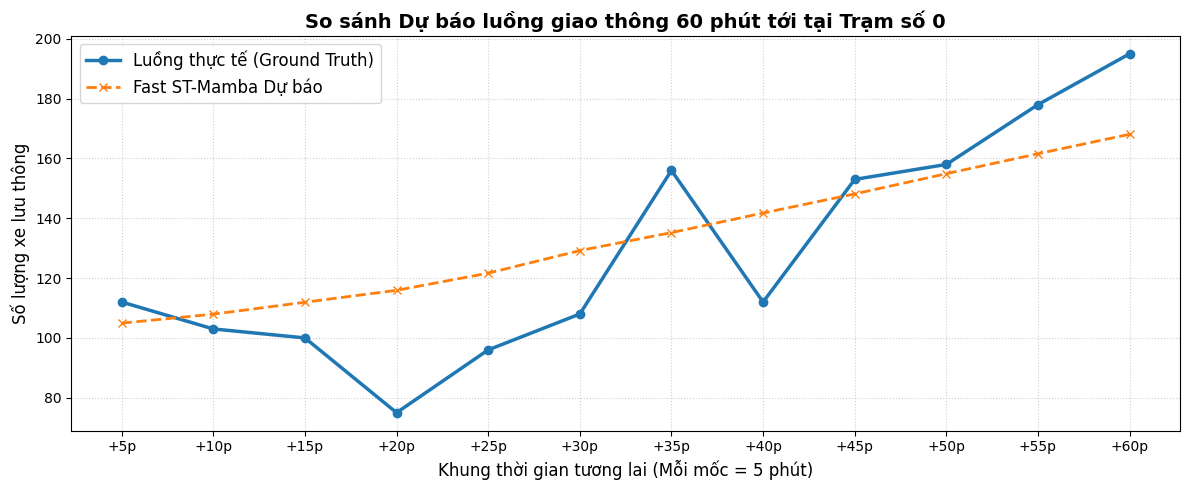

In [33]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# 1. TẢI MÔ HÌNH VÀ KHỞI TẠO CHẾ ĐỘ KIỂM THỬ
print("TẢI TRỌNG SỐ MÔ HÌNH TỐT NHẤT...")
model.load_state_dict(torch.load("best_st_mamba_model.pth"))
model.eval()  

test_loss = 0.0
total_mae = 0.0
total_rmse = 0.0
num_samples = 0

all_preds = []
all_targets = []

# 2. CHẠY KIỂM THỬ TRÊN TOÀN BỘ TẬP TEST_LOADER
print("ĐANG ĐÁNH GIÁ TRÊN TẬP TEST...")
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        # Dự báo từ mô hình
        outputs = model(batch_x, adj_tensor)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item() * batch_x.size(0)
        
        # GIẢI CHUẨN HÓA (Đưa từ Z-Score về số xe thực tế)
        outputs_real = outputs * flow_std + flow_mean
        batch_y_real = batch_y * flow_std + flow_mean
        
        mae = torch.abs(outputs_real - batch_y_real).mean().item()
        mse = torch.mean((outputs_real - batch_y_real) ** 2).item()
        
        total_mae += mae * batch_x.size(0)
        total_rmse += mse * batch_x.size(0)
        num_samples += batch_x.size(0)
        
        if len(all_preds) == 0:
            all_preds.append(outputs_real.cpu().numpy())
            all_targets.append(batch_y_real.cpu().numpy())

final_mse = test_loss / num_samples
final_mae = total_mae / num_samples
final_rmse = np.sqrt(total_rmse / num_samples)

print("\nKẾT QUẢ")
print(f"Test Normalized MSE : {final_mse:.4f}")
print(f"Test Real MAE        : {final_mae:.2f} (xe / mốc 5 phút)")
print(f"Test Real RMSE       : {final_rmse:.2f} (xe / mốc 5 phút)")

# 3. TRỰC QUAN HÓA KẾT QUẢ BẰNG MATPLOTLIB
preds_real = all_preds[0]
y_real = all_targets[0]

sample_idx = 0   # Lấy mẫu dữ liệu đầu tiên trong batch
node_idx = 0     # Dự báo tại Trạm cảm biến số 0 (Bạn có thể đổi từ 0 đến 306)

# Trích xuất chuỗi thời gian tương lai 12 mốc (60 phút)
pred_series = preds_real[sample_idx, :, node_idx, 0]
true_series = y_real[sample_idx, :, node_idx, 0]

plt.figure(figsize=(12, 5))

# Vẽ đường thực tế
plt.plot(true_series, label="Luồng thực tế (Ground Truth)", marker='o', linewidth=2.5, color='#1f77b4')

# Vẽ đường dự báo của Fast ST-Mamba
plt.plot(pred_series, label="Fast ST-Mamba Dự báo", marker='x', linewidth=2, linestyle='--', color='#ff7f0e')

plt.title(f"So sánh Dự báo luồng giao thông 60 phút tới tại Trạm số {node_idx}", fontsize=14, fontweight='bold')
plt.xlabel("Khung thời gian tương lai (Mỗi mốc = 5 phút)", fontsize=12)
plt.ylabel("Số lượng xe lưu thông", fontsize=12)

# Định dạng các cột thời gian +5p, +10p... +60p
plt.xticks(range(12), [f"+{i*5}p" for i in range(1, 13)])
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [36]:
# 1. TEMPORAL PROCESSOR: Multi-Level Causal Attention (MLCA)
class TemporalCausalAttention(nn.Module):
    """
    Cơ chế Attention nhân quả theo thời gian có hỗ trợ Cửa sổ (Window Masking).
    Đảm bảo nút tại thời điểm t chỉ có thể nhìn thấy dữ liệu từ (t - window) đến t.
    """
    def __init__(self, d_model, num_heads, window_size=None):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.window_size = window_size
        self.head_dim = d_model // num_heads
        
        self.qkv = nn.Linear(d_model, d_model * 3)
        self.proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, x):
        # x shape: [B, N, T, D]
        B, N, T, D = x.shape
        x_flat = x.reshape(B * N, T, D)
        
        qkv = self.qkv(x_flat).reshape(B * N, T, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2] # [B*N, heads, T, head_dim]
        
        # Tính toán ma trận Attention
        attn = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim) # [B*N, heads, T, T]
        
        # MASK 1: Causal Mask (Tuân thủ luật nhân quả
        # Chặn toàn bộ liên kết từ tương lai (t+1, t+2...) rò rỉ về hiện tại (t)
        causal_mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        attn.masked_fill_(causal_mask, float('-inf'))
        
        # MASK 2: Window Mask (Xử lý theo cấp độ Local -> Global)
        # Giới hạn tầm nhìn quá khứ trong một khung cửa sổ nhất định
        if self.window_size is not None and self.window_size < T:
            window_mask = torch.tril(torch.ones(T, T, device=x.device), diagonal=-self.window_size).bool()
            attn.masked_fill_(window_mask, float('-inf'))
            
        attn = attn.softmax(dim=-1)
        attn = self.dropout(attn)

        out = (attn @ v).transpose(1, 2).reshape(B * N, T, D)
        out = self.proj(out)
        return out.view(B, N, T, D)

# 2. SPATIAL PROCESSOR: Node-Identity-Aware Spatial Attention
class NodeIdentitySpatialAttention(nn.Module):
    """
    Khai thác tương quan không gian kết hợp Nhúng định danh Nút (Node Identity).
    Thay vì dùng ma trận GCN, nó dùng cơ chế Attention Self-Directed thuần túy.
    """
    def __init__(self, d_model, num_heads, num_nodes):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        
        # KEY COMPONENT: Nhúng định danh trạm vật lý có thể học được (Learnable Parameter)
        self.node_emb = nn.Parameter(torch.randn(1, num_nodes, 1, d_model))
        
        self.qkv = nn.Linear(d_model, d_model * 3)
        self.proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, x):
        # x shape: [B, N, T, D]
        B, N, T, D = x.shape
        
        x_ident = x + self.node_emb
    
        x_spatial = x_ident.transpose(1, 2).reshape(B * T, N, D)
        
        qkv = self.qkv(x_spatial).reshape(B * T, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2] # [B*T, heads, N, head_dim]
        
        attn = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn = attn.softmax(dim=-1)
        attn = self.dropout(attn)
        
        out = (attn @ v).transpose(1, 2).reshape(B * T, N, D)
        out = self.proj(out)
        
        return out.view(B, T, N, D).transpose(1, 2)

# 3. MLCA BLOCK (Cascade Fusion)
class MLCAformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, num_nodes, window_size):
        super().__init__()
        self.spatial_attn = NodeIdentitySpatialAttention(d_model, num_heads, num_nodes)
        self.temporal_causal_attn = TemporalCausalAttention(d_model, num_heads, window_size)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(0.1)
        )

    def forward(self, x):
        # Khối Không gian (Spatial)
        x = x + self.spatial_attn(self.norm1(x))
        # Khối Thời gian Nhân quả (Temporal MLCA)
        x = x + self.temporal_causal_attn(self.norm2(x))
        # Feed-Forward Network
        x = x + self.ffn(self.norm3(x))
        return x

# 4. TRẠM CHỈ HUY: FULL MLCAFORMER NETWORK
class MLCAFormer(nn.Module):
    def __init__(self, num_nodes, in_features, seq_len, pred_len, d_model=32, num_heads=4, num_layers=3):
        super().__init__()
        self.num_nodes = num_nodes
        self.pred_len = pred_len
        self.d_model = d_model
        
        self.input_proj = nn.Linear(in_features, d_model)
        
        # Cấu trúc Phân cấp (Hierarchical Structure) lõi của MLCAFormer
        # Đi từ cửa sổ quét cực ngắn (3 mốc), trung hạn (6 mốc), đến toàn cục (None = full seq_len)
        window_sizes = [3, 6, None] 
        
        self.layers = nn.ModuleList([
            MLCAformerBlock(d_model, num_heads, num_nodes, window_size=window_sizes[i % len(window_sizes)])
            for i in range(num_layers)
        ])
        
        # Hồi quy Đầu ra
        self.regression = nn.Sequential(
            nn.Linear(seq_len * d_model, 128),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(128, pred_len * 1) 
        )

    def forward(self, x, adj_matrix=None):
        """
        Lưu ý: Không giống GNN, cơ chế Spatial Identity Awareness của Transformer này 
        sẽ tự học cấu trúc qua dữ liệu nên ta KHÔNG cần dùng đến adj_matrix.
        Tuy nhiên hàm vẫn nhận vào để tương thích với Training Loop cũ của bạn.
        """
        # x ban đầu từ dataloader: [B, SEQ_LEN, N, C]
        B, T, N, C = x.shape
        
        # Chuyển form để tương thích hệ thống: [B, N, T, C]
        h = x.transpose(1, 2) 
        h = self.input_proj(h) # [B, N, T, d_model]
        
        # Đi qua các tháp phân cấp MLCA
        for layer in self.layers:
            h = layer(h)
            
        # Phẳng hóa để đưa vào Regression: [B, N, T * d_model]
        h_flat = h.reshape(B, N, T * self.d_model)
        out = self.regression(h_flat) # [B, N, pred_len]
        
        # Format lại Output về chuẩn hệ thống: [B, pred_len, N, 1]
        out = out.view(B, N, self.pred_len, 1).transpose(1, 2)
        
        return out

In [39]:
model = MLCAFormer(
    num_nodes=num_nodes, 
    in_features=3, 
    seq_len=SEQ_LEN, 
    pred_len=PRED_LEN, 
    d_model=D_MODEL, 
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS
).to(device)

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Đường dẫn lưu mô hình MLCAFormer tốt nhất
mlca_save_path = "best_mlcaformer_model.pth"
best_val_loss = float('inf')

# -------------------------------------------------------------------------
# HÀM ĐÁNH GIÁ (VALIDATION / TESTING) ĐỘC LẬP
# -------------------------------------------------------------------------
def evaluate_mlca(loader, model, criterion, flow_mean, flow_std, device):
    model.eval()
    total_loss = 0.0
    total_mae = 0.0
    num_samples = 0
    
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            
            total_loss += loss.item() * batch_x.size(0)
            
            outputs_real = outputs * flow_std + flow_mean
            batch_y_real = batch_y * flow_std + flow_mean
            
            mae = torch.abs(outputs_real - batch_y_real).mean().item()
            total_mae += mae * batch_x.size(0)
            num_samples += batch_x.size(0)
            
    return total_loss / num_samples, total_mae / num_samples


# 📝 2. THÊM VÀO ĐÂY: Khởi tạo WandB cho MLCAFormer
# Vẫn giữ nguyên project="DPL302m_Project" để nó vẽ đè lên chung biểu đồ với ST-Mamba
wandb.init(
    project="DPL302m_Project", 
    name="MLCAFormer_Run",     # Tên mới để phân biệt màu đường đồ thị
    config={
        "d_model": D_MODEL,
        "num_heads": NUM_HEADS,
        "num_layers": NUM_LAYERS,
        "epochs": EPOCHS,
        "learning_rate": 0.001,
        "optimizer": "AdamW",
        "architecture": "MLCAFormer"
    }
)

# VÒNG LẶP HUẤN LUYỆN CHÍNH (TRAINING LOOP)
print("BẮT ĐẦU HUẤN LUYỆN MLCAFORMER")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    num_samples = 0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    
    for batch_x, batch_y in loop:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        
        # Forward Pass
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        
        # Backward Pass
        loss.backward()
        
        # Chống bùng nổ đạo hàm cho cơ chế Attention
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        
        optimizer.step()
        
        train_loss += loss.item() * batch_x.size(0)
        num_samples += batch_x.size(0)
        
        loop.set_postfix(loss=loss.item())
        
    avg_train_loss = train_loss / num_samples
    
    # Đánh giá sau mỗi epoch
    val_loss, val_mae = evaluate_mlca(val_loader, model, criterion, flow_mean, flow_std, device)
    
    print(f"🔹 Epoch {epoch+1:02d}/{EPOCHS} | Train MSE: {avg_train_loss:.4f} | Val MSE: {val_loss:.4f} | Val MAE: {val_mae:.2f} (xe)")
    
    # Gửi dữ liệu epoch hiện tại lên web
    wandb.log({
        "epoch": epoch + 1,
        "Train MSE": avg_train_loss,
        "Val MSE": val_loss,
        "Val MAE": val_mae
    })
    
    # Early Stopping: Lưu checkpoint tốt nhất
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), mlca_save_path)
        print(f"   -> Đã lưu Checkpoint MLCAformer mới!")

# Đóng luồng truyền dữ liệu khi kết thúc training
wandb.finish()

print("\nHOÀN TẤT HUẤN LUYỆN MLCAFORMER!")
print(f"Mô hình tốt nhất được lưu tại: {mlca_save_path}")

NameError: name 'NUM_HEADS' is not defined

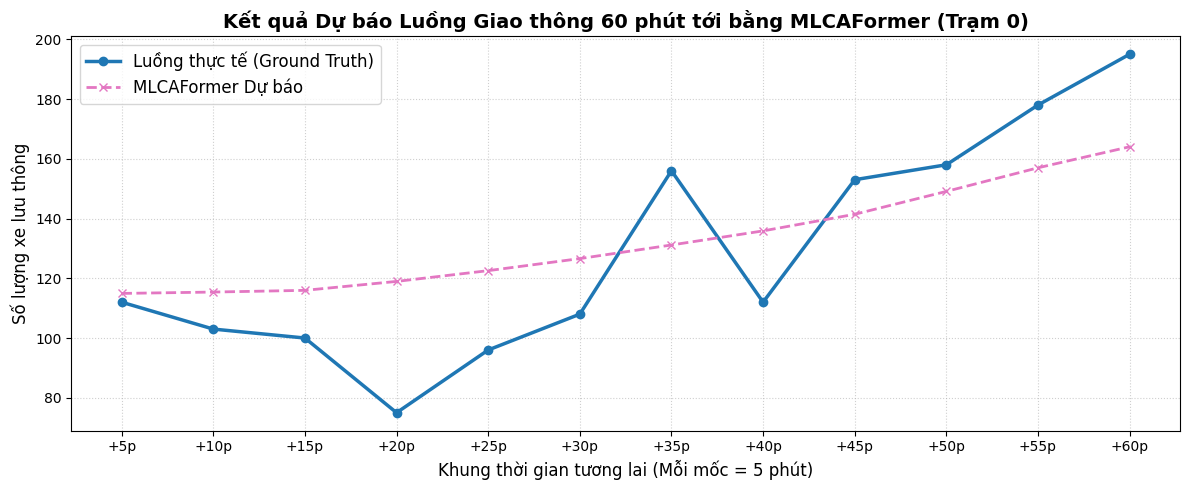

In [23]:
import matplotlib.pyplot as plt

model.load_state_dict(torch.load(mlca_save_path))
model.eval()

test_batch_x, test_batch_y = next(iter(test_loader))
test_batch_x = test_batch_x.to(device)
test_batch_y = test_batch_y.to(device)

with torch.no_grad():
    preds = model(test_batch_x)

preds_real = (preds * flow_std + flow_mean).cpu().numpy()
y_real = (test_batch_y * flow_std + flow_mean).cpu().numpy()

sample_idx = 0
node_idx = 0

pred_series = preds_real[sample_idx, :, node_idx, 0]
true_series = y_real[sample_idx, :, node_idx, 0]

# Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 5))
plt.plot(true_series, label="Luồng thực tế (Ground Truth)", marker='o', linewidth=2.5, color='#1f77b4')
plt.plot(pred_series, label="MLCAFormer Dự báo", marker='x', linewidth=2, linestyle='--', color='#e377c2')
plt.title(f"Kết quả Dự báo Luồng Giao thông 60 phút tới bằng MLCAFormer (Trạm {node_idx})", fontsize=14, fontweight='bold')
plt.xlabel("Khung thời gian tương lai (Mỗi mốc = 5 phút)", fontsize=12)
plt.ylabel("Số lượng xe lưu thông", fontsize=12)
plt.xticks(range(12), [f"+{i*5}p" for i in range(1, 13)])
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [36]:
class ST_ODE_Func(nn.Module):
    """
    Hàm ODE tính toán tốc độ thay đổi của luồng giao thông dựa trên cấu trúc đồ thị.
    Sử dụng Graph Convolution Network (GCN) tiêu chuẩn, cực kỳ tiết kiệm bộ nhớ.
    """
    def __init__(self, d_model):
        super().__init__()
        self.w1 = nn.Parameter(torch.FloatTensor(d_model, d_model))
        self.w2 = nn.Parameter(torch.FloatTensor(d_model, d_model))
        self.relu = nn.ReLU()
        
        nn.init.xavier_uniform_(self.w1)
        nn.init.xavier_uniform_(self.w2)

    def forward(self, h, adj):
        x = torch.einsum('ij,bjd->bid', adj, h) 
        x = torch.matmul(x, self.w1)
        x = self.relu(x)
        
        x = torch.einsum('ij,bjd->bid', adj, x)
        x = torch.matmul(x, self.w2)
        
        return x 

# 2. ST-NODE MAIN NETWORK
class STNODE(nn.Module):
    def __init__(self, num_nodes, in_features, seq_len, pred_len, d_model=32, dt=0.1):
        super().__init__()
        self.pred_len = pred_len
        self.d_model = d_model
        self.dt = dt 
        
        self.encoder = nn.GRU(input_size=in_features, hidden_size=d_model, batch_first=True)
        
        self.ode_func = ST_ODE_Func(d_model)
        
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, x, adj_matrix):
        B, T, N, C = x.shape
        
        x_rnn = x.transpose(1, 2).reshape(B * N, T, C)
        
        _, h_0 = self.encoder(x_rnn) # [1, B*N, d_model]
        
        h_t = h_0.squeeze(0).view(B, N, self.d_model) 
        
        outputs = []
        for _ in range(self.pred_len):
            # Tính đạo hàm: Tốc độ thay đổi của luồng giao thông tại thời điểm hiện tại
            dh = self.ode_func(h_t, adj_matrix)
            
            # Cập nhật tương lai: h(t + dt) = h(t) + dh * dt
            h_t = h_t + dh * self.dt
            
            # Dự báo số lượng xe:
            out = self.decoder(h_t) # [B, N, 1]
            outputs.append(out)
            
        # outputs đang là list của 12 Tensor, gộp lại thành: [B, PRED_LEN, N, 1]
        outputs = torch.stack(outputs, dim=1)
        
        return outputs

In [37]:
# KHỞI TẠO LẠI MÔ HÌNH ST-NODE (Ghi rõ tên tham số để tránh lệch vị trí)
model = STNODE(
    num_nodes=num_nodes,   
    in_features=3,
    seq_len=12,         
    pred_len=12,          
    d_model=32,         
    dt=0.1                
).to(device)

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

stnode_save_path = "best_stnode_model.pth"
best_val_loss = float('inf')

print("Dự báo của ST-NODE thành 12 bước thành công!")

✅ Đã sửa và đồng bộ kích thước dự báo của ST-NODE thành 12 bước thành công!


In [38]:
# 3. HÀM ĐÁNH GIÁ (VALIDATION / TESTING) CHO ST-NODE
wandb.init(
    project="DPL302m_Project",
    name="ST_NODE_Run",    
    config={
        "d_model": 32,
        "dt": 0.1,
        "epochs": 30,
        "learning_rate": 0.001,
        "optimizer": "AdamW",
        "architecture": "ST-NODE"
    }
)

adj_tensor = torch.tensor(normalized_adj, dtype=torch.float32).to(device)

def evaluate_stnode(loader, model, criterion, adj, flow_mean, flow_std, device):
    model.eval()
    total_loss = 0.0
    total_mae = 0.0
    num_samples = 0
    
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            # Forward pass
            outputs = model(batch_x, adj)
            loss = criterion(outputs, batch_y)
            
            total_loss += loss.item() * batch_x.size(0)
            
            # Giải chuẩn hóa về đơn vị số xe thực tế để tính MAE
            outputs_real = outputs * flow_std + flow_mean
            batch_y_real = batch_y * flow_std + flow_mean
            
            mae = torch.abs(outputs_real - batch_y_real).mean().item()
            total_mae += mae * batch_x.size(0)
            num_samples += batch_x.size(0)
            
    return total_loss / num_samples, total_mae / num_samples

# 4. VÒNG LẶP HUẤN LUYỆN CHÍNH (TRAINING LOOP)
print("BẮT ĐẦU HUẤN LUYỆN ST-NODE...")
EPOCHS = 30 # Bạn có thể chỉnh lại số lượng Epoch mong muốn ở đây

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    num_samples = 0
    
    # Tạo thanh tiến trình trực quan
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    
    for batch_x, batch_y in loop:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        
        # Forward Pass
        outputs = model(batch_x, adj_tensor)
        loss = criterion(outputs, batch_y)
        
        # Backward Pass
        loss.backward()
        
        # Cắt tỉa đạo hàm chống bùng nổ đạo hàm (Gradient Clipping)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        
        optimizer.step()
        
        train_loss += loss.item() * batch_x.size(0)
        num_samples += batch_x.size(0)
        
        loop.set_postfix(loss=loss.item())
        
    avg_train_loss = train_loss / num_samples
    
    # Đánh giá trên tập Validation
    val_loss, val_mae = evaluate_stnode(val_loader, model, criterion, adj_tensor, flow_mean, flow_std, device)
    
    print(f"🔹 Epoch {epoch+1:02d}/{EPOCHS} | Train MSE: {avg_train_loss:.4f} | Val MSE: {val_loss:.4f} | Val MAE: {val_mae:.2f} (xe)")
    
    # Kỹ thuật Early Stopping: Lưu lại trọng số model tốt nhất
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), stnode_save_path)
        print(f"   -> Đã lưu Checkpoint ST-NODE mới!")

print("\nHOÀN TẤT HUẤN LUYỆN ST-NODE!")
print(f"Mô hình tốt nhất được lưu tại: {stnode_save_path}")

🚀 BẮT ĐẦU HUẤN LUYỆN ST-NODE...


🔹 Epoch 01/30 | Train MSE: 0.0879 | Val MSE: 0.0751 | Val MAE: 28.20 (xe)
   -> 💾 Đã lưu Checkpoint ST-NODE mới!


🔹 Epoch 02/30 | Train MSE: 0.0683 | Val MSE: 0.0719 | Val MAE: 27.11 (xe)
   -> 💾 Đã lưu Checkpoint ST-NODE mới!


🔹 Epoch 03/30 | Train MSE: 0.0673 | Val MSE: 0.0712 | Val MAE: 27.01 (xe)
   -> 💾 Đã lưu Checkpoint ST-NODE mới!


🔹 Epoch 04/30 | Train MSE: 0.0663 | Val MSE: 0.0702 | Val MAE: 26.91 (xe)
   -> 💾 Đã lưu Checkpoint ST-NODE mới!


...

🔹 Epoch 26/30 | Train MSE: 0.0620 | Val MSE: 0.0674 | Val MAE: 26.39 (xe)


🔹 Epoch 27/30 | Train MSE: 0.0618 | Val MSE: 0.0685 | Val MAE: 26.58 (xe)


🔹 Epoch 28/30 | Train MSE: 0.0618 | Val MSE: 0.0661 | Val MAE: 26.06 (xe)
   -> 💾 Đã lưu Checkpoint ST-NODE mới!


🔹 Epoch 29/30 | Train MSE: 0.0617 | Val MSE: 0.0663 | Val MAE: 25.99 (xe)


🔹 Epoch 30/30 | Train MSE: 0.0616 | Val MSE: 0.0682 | Val MAE: 26.62 (xe)

🎉 HOÀN TẤT HUẤN LUYỆN ST-NODE!
Mô hình tốt nhất được lưu tại: best_stnode_model.pth


🔍 ĐANG TẢI TRỌNG SỐ MÔ HÌNH ST-NODE TỐT NHẤT...
🧠 ĐANG ĐÁNH GIÁ HIỆU NĂNG TRÊN TẬP TEST...

================ THÀNH QUẢ KIỂM THỬ ST-NODE ================
📊 Test Normalized MSE : 0.0612
🚗 Test Real MAE        : 25.17 (xe / mốc 5 phút)
📈 Test Real RMSE       : 38.70 (xe / mốc 5 phút)


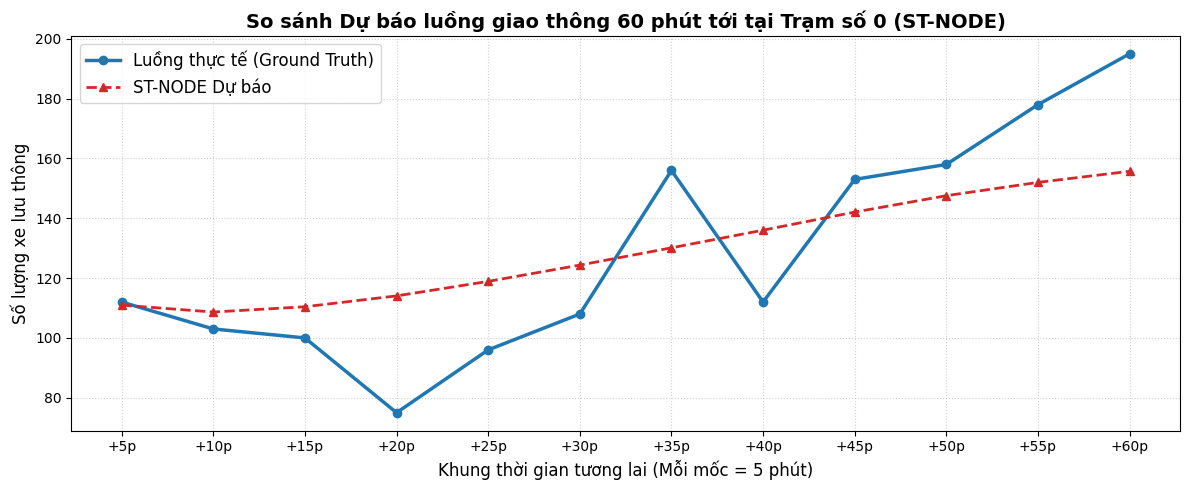

In [39]:
print("ĐANG TẢI TRỌNG SỐ MÔ HÌNH ST-NODE TỐT NHẤT")
model.load_state_dict(torch.load("best_stnode_model.pth"))
model.eval() 

test_loss = 0.0
total_mae = 0.0
total_rmse = 0.0
num_samples = 0

all_preds = []
all_targets = []

# 2. CHẠY KIỂM THỬ TRÊN TOÀN BỘ TẬP TEST_LOADER
print("ĐÁNH GIÁ HIỆU NĂNG TRÊN TẬP TEST")
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        # Dự báo từ mô hình ST-NODE (yêu cầu đầu vào batch_x và ma trận adj_tensor)
        outputs = model(batch_x, adj_tensor)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item() * batch_x.size(0)
        
        # GIẢI CHUẨN HÓA (Đưa giá trị từ Z-Score về số lượng xe thực tế)
        outputs_real = outputs * flow_std + flow_mean
        batch_y_real = batch_y * flow_std + flow_mean
        
        # Tính MAE, MSE cục bộ cho batch
        mae = torch.abs(outputs_real - batch_y_real).mean().item()
        mse = torch.mean((outputs_real - batch_y_real) ** 2).item()
        
        total_mae += mae * batch_x.size(0)
        total_rmse += mse * batch_x.size(0)
        num_samples += batch_x.size(0)
        
        # Lưu lại batch đầu tiên để phục vụ vẽ biểu đồ minh họa
        if len(all_preds) == 0:
            all_preds.append(outputs_real.cpu().numpy())
            all_targets.append(batch_y_real.cpu().numpy())

# Tính toán các chỉ số lỗi trung bình cuối cùng trên toàn tập kiểm thử
final_mse = test_loss / num_samples
final_mae = total_mae / num_samples
final_rmse = np.sqrt(total_rmse / num_samples)

print("\nKẾT QUẢ KIỂM THỬ ST-NODE")
print(f"Test Normalized MSE : {final_mse:.4f}")
print(f"Test Real MAE        : {final_mae:.2f} (xe / mốc 5 phút)")
print(f"Test Real RMSE       : {final_rmse:.2f} (xe / mốc 5 phút)")

# 3. TRỰC QUAN HÓA KẾT QUẢ BẰNG MATPLOTLIB
preds_real = all_preds[0]
y_real = all_targets[0]

sample_idx = 0   # Lấy mẫu dữ liệu đầu tiên trong batch kiểm thử
node_idx = 0     # Dự báo tại Trạm cảm biến số 0 (Bạn có thể đổi từ 0 đến 306 tùy ý)

# Trích xuất chuỗi thời gian tương lai 12 mốc (tương đương dự báo trước 60 phút)
pred_series = preds_real[sample_idx, :, node_idx, 0]
true_series = y_real[sample_idx, :, node_idx, 0]

plt.figure(figsize=(12, 5))

# Vẽ đường thực tế
plt.plot(true_series, label="Luồng thực tế (Ground Truth)", marker='o', linewidth=2.5, color='#1f77b4')

# Vẽ đường dự báo của ST-NODE để so sánh hiệu năng
plt.plot(pred_series, label="ST-NODE Dự báo", marker='^', linewidth=2, linestyle='--', color='#d62728')

plt.title(f"So sánh Dự báo luồng giao thông 60 phút tới tại Trạm số {node_idx} (ST-NODE)", fontsize=14, fontweight='bold')
plt.xlabel("Khung thời gian tương lai (Mỗi mốc = 5 phút)", fontsize=12)
plt.ylabel("Số lượng xe lưu thông", fontsize=12)

# Định dạng nhãn trục hoành hiển thị dạng dòng thời gian tiến lên: +5p, +10p... +60p
plt.xticks(range(12), [f"+{i*5}p" for i in range(1, 13)])
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [48]:
def evaluate_advanced(loader, model, model_type, adj, flow_mean, flow_std, device):
    """
    Hàm kiểm thử nâng cao tính toán bộ 4 metrics: MAE, RMSE, MAPE, R2
    model_type: 'mamba' hoặc 'mlca' hoặc 'stnode' (vì cách truyền tham số forward khác nhau)
    """
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            
            # Khớp hàm forward tùy thuộc vào từng kiến trúc mô hình
            if model_type == 'mlca':
                outputs = model(batch_x)
            elif model_type in ['mamba', 'stnode']:
                outputs = model(batch_x, adj)
                
            # Giải chuẩn hóa Z-Score về số lượng xe thực tế
            outputs_real = outputs * flow_std + flow_mean
            batch_y_real = batch_y * flow_std + flow_mean
            
            all_preds.append(outputs_real.cpu().numpy())
            all_targets.append(batch_y_real.cpu().numpy())
            
    # Gộp toàn bộ dữ liệu kiểm thử lại thành mảng lớn
    y_pred = np.concatenate(all_preds, axis=0)
    y_true = np.concatenate(all_targets, axis=0)
    
    # --- TÍNH TOÁN CÁC METRICS TỔNG THỂ ---
    # 1. MAE
    mae = np.mean(np.abs(y_true - y_pred))
    
    # 2. RMSE
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    
    # 3. MAPE (Tránh chia cho 0 tại những thời điểm không có xe bằng cách tạo mặt nạ mask)
    mask = y_true > 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    
    # 4. R2 Score (Duỗi phẳng mảng đa chiều thành 1D để tính toán toàn cục)
    r2 = r2_score(y_true.flatten(), y_pred.flatten())
    
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}

In [49]:
results = {}

# 1. Đánh giá mô hình Fast ST-Mamba
try:
    print("Đang tải và đánh giá Fast ST-Mamba...")
    # Khởi tạo cấu trúc nền (Thay thế bằng hàm init chuẩn của bạn nếu cần)
    model_mamba = STMambaHybridModel(num_nodes=num_nodes, in_features=3, seq_len=12, pred_len=12).to(device)
    model_mamba.load_state_dict(torch.load("best_st_mamba_model.pth", map_location=device))
    results["Fast ST-Mamba"] = evaluate_advanced(test_loader, model_mamba, 'mamba', adj_tensor, flow_mean, flow_std, device)
except Exception as e:
    print(f"Không đánh giá được Mamba do: {e}")

# 2. Đánh giá mô hình MLCAFormer
try:
    print("Đang tải và đánh giá MLCAFormer...")
    model_mlca = MLCAFormer(num_nodes=num_nodes, in_features=3, seq_len=12, pred_len=12).to(device)
    model_mlca.load_state_dict(torch.load("best_mlcaformer_model.pth", map_location=device))
    results["MLCAFormer"] = evaluate_advanced(test_loader, model_mlca, 'mlca', adj_tensor, flow_mean, flow_std, device)
except Exception as e:
    print(f"Không đánh giá được MLCAFormer do: {e}")

# 3. Đánh giá mô hình ST-NODE
try:
    print("Đang tải và đánh giá ST-NODE...")
    model_node = STNODE(num_nodes=num_nodes, in_features=3, seq_len=12, pred_len=12).to(device)
    model_node.load_state_dict(torch.load("best_stnode_model.pth", map_location=device))
    results["ST-NODE (Ours)"] = evaluate_advanced(test_loader, model_node, 'stnode', adj_tensor, flow_mean, flow_std, device)
except Exception as e:
    print(f"Không đánh giá được ST-NODE do: {e}")

# --- IN BẢNG KẾT QUẢ SO SÁNH ---
print("\n" + "="*55)
print(f"{'MÔ HÌNH':<20} | {'MAE ↓':<8} | {'RMSE ↓':<8} | {'MAPE ↓ (%)':<10} | {'R² ↑':<6}")
print("="*55)
for model_name, metrics in results.items():
    print(f"{model_name:<20} | {metrics['MAE']:<8.2f} | {metrics['RMSE']:<8.2f} | {metrics['MAPE']:<10.2f} | {metrics['R2']:<6.4f}")
print("="*55)

⏳ Đang tải và đánh giá Fast ST-Mamba...
⏳ Đang tải và đánh giá MLCAFormer...
⏳ Đang tải và đánh giá ST-NODE...

MÔ HÌNH              | MAE ↓    | RMSE ↓   | MAPE ↓ (%) | R² ↑  
Fast ST-Mamba        | 24.31    | 37.01    | 18.70      | 0.9453
MLCAFormer           | 20.22    | 32.25    | 14.84      | 0.9584
ST-NODE (Ours)       | 25.17    | 38.70    | 18.48      | 0.9402


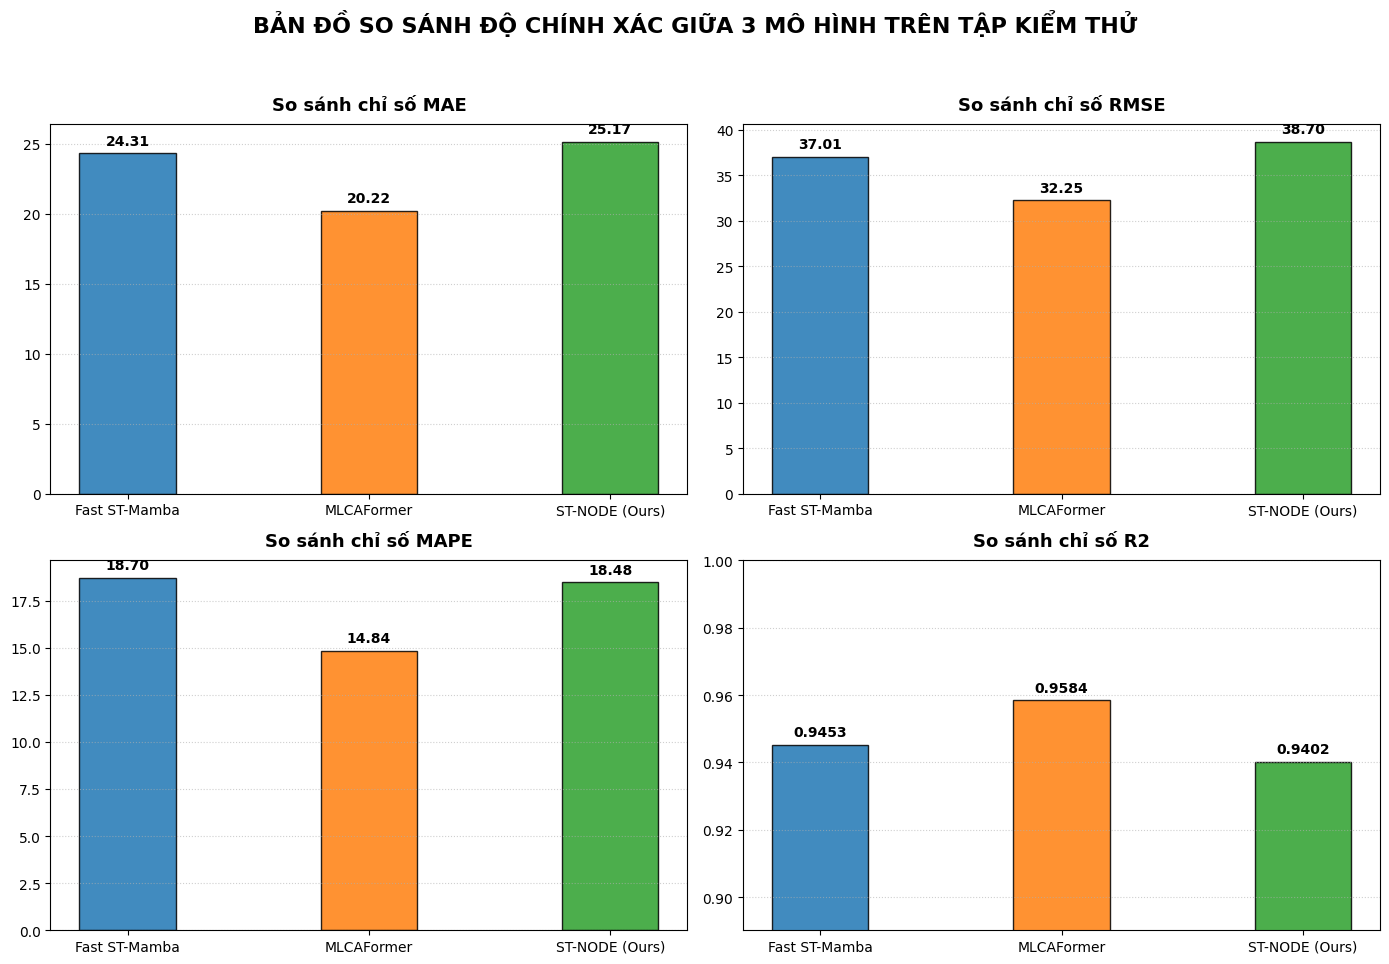

In [50]:
import matplotlib.pyplot as plt

models = list(results.keys())
metrics_list = ["MAE", "RMSE", "MAPE", "R2"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Mỗi mô hình 1 màu đặc trưng riêng biệt

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for idx, metric in enumerate(metrics_list):
    # Lấy giá trị của từng mô hình đối với metric hiện tại
    values = [results[model][metric] for model in models]
    
    # Vẽ biểu đồ thanh vuông vức, khoảng cách cột rộng rãi rõ ràng
    bars = axs[idx].bar(models, values, color=colors, width=0.4, edgecolor='black', alpha=0.85)
    
    axs[idx].set_title(f"So sánh chỉ số {metric}", fontsize=13, fontweight='bold', pad=10)
    axs[idx].grid(axis='y', linestyle=':', alpha=0.6)
    
    # Thiết lập giới hạn trục Y cho R2 để thấy rõ độ chênh lệch nhỏ
    if metric == "R2":
        axs[idx].set_ylim(min(values) - 0.05, 1.0)
        
    # Ghi số liệu cụ thể lên đỉnh mỗi cột (Tách rời cột, không đè chữ)
    for bar in bars:
        height = bar.get_height()
        fmt = f'{height:.4f}' if metric == "R2" else f'{height:.2f}'
        axs[idx].annotate(fmt,
                          xy=(bar.get_x() + bar.get_width() / 2, height),
                          xytext=(0, 4),  # Đẩy chữ lên phía trên đỉnh cột 4 pixel
                          textcoords="offset points",
                          ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle("BẢN ĐỒ SO SÁNH ĐỘ CHÍNH XÁC GIỮA 3 MÔ HÌNH TRÊN TẬP KIỂM THỬ", fontsize=16, fontweight='bold', y=0.96)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()